In [1]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er
import matplotlib.pyplot as plt
import seaborn as sns
from keras import backend as K
import tensorflow as tf
import tensorflow as tf
import os
import json
from contextlib import redirect_stdout
import yaml
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

2024-05-01 16:32:21.452852: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-01 16:32:21.455157: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-01 16:32:21.484675: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-01 16:32:21.484712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-01 16:32:21.485826: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
epochs = 1500
batch_size = 512
validation_split = 0.2
lasso_alpha = 0.01
two_step_normalization = True


## Defining the fuctions

### prepare folder

In [3]:
def create_new_folder(base_path="Results"):
    # Check if the Results directory exists, if not, create it
    # get files that contain the word "result_RNAseq_SMOTE" and are directories
    results_dir = os.path.join(base_path, "Model_outputs")
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Find existing result folders and determine the next number
    existing_folders = [name for name in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, name)) and "result_microarray_SMOTE" in name]
    if not existing_folders:
        next_number = 1
    else:
        # Sort existing folders to get the highest numbered folder
        existing_folders.sort()
        last_folder = existing_folders[-1]
        last_number = int(last_folder.replace("result_microarray_SMOTE", ""))
        next_number = last_number + 1

    # Generate the name for the new folder
    new_folder_name = "result_microarray_SMOTE{:02d}".format(next_number)
    new_folder_path = os.path.join(results_dir, new_folder_name)

    # Create the new folder
    os.makedirs(new_folder_path)

    return new_folder_path

In [4]:
def save_performance_results(results, my_model):
    def analyze_restults(results, my_model):
        #results["Sex"] = my_model.z_test["Sex"].values
        #results["Status"] = my_model.z_test["Status"].values

        results["absolute_error"] = abs(results["Actual"]-results["Predicted"])
        results["big_absolute_error"] = np.where(results["absolute_error"] < 5, 0, results["absolute_error"])
        return results

    results = analyze_restults(results, my_model)
    with open(f"{m.output_directory}/model_summary.txt", "a") as f:
        # Redirect the stdout to the file
        with redirect_stdout(f):
            print("/n/t Actual age distribution:")
            print(results["Actual"].describe())
            print("/n/t Predicted age distribution:")
            print(results["Predicted"].describe())
            print("/n/t Predicted absolute error distribution:")
            print(results["absolute_error"].describe())
            print("/n/n/t /t Is the experiment acting the outcome?/n")
            
            #print("/n/t Error distribution absolute_error ~ Age anova_lm:")
            #print(er.evaluate_error_experiment(results, groups=["Age"]))
            #print("/n/t Krustal Wallis test:")
            #print (er.evaluate_Kruskal_Wallis(results,groups=["Age"]))
            #print("/n/t Dunnes test:")
            #print(er.evaluate_Dunnes_test(results, groups=["Age"]))
    #er.plot_Dunes_result(er.evaluate_Dunnes_test(results), save=True, file_name=f"{m.output_directory}/Dunnes_test.png")


### Plots

In [5]:
def plot_distrobution_features(expression_df, age:list, n_features=None):
    def map_age(age):
        if age == 35:
            return 'Y'
        elif age > 65:
            return 'O'
        else:
            return 'M'
    x = expression_df
    if n_features:
        x=x.sample(n=n_features, axis='columns')
    x["Age"] = age.apply(lambda age: map_age(age))
    data = x
    melted_data = pd.melt(data,id_vars="Age",
                    var_name="features",
                    value_name='value')

    plt.figure(figsize=(10,10))
    sns.violinplot(x="features", y="value", hue="Age", data=melted_data,split=True, inner="quart")
    plt.xticks(rotation=90)


    #sns.boxplot(x="features", y="value", hue="Age", data=melted_data, showfliers=False)
    #plt.xticks(rotation=90)
    return melted_data


In [6]:
def map_to_category(age):
    if age < 35:
        return "Young"
    elif age > 65:
        return "Old"
    else:
        return "MiddleAge"

In [7]:
def color_feature_selction_TSNE(df):
    """
    make sure df has the expression and the column Age
    """
    feature_df = pd.DataFrame(df)
    feature_df_t = pd.DataFrame(df) 
    feature_df_t["Age"]=  [map_to_category(age) for age in df["Age"]] 
    tab20_colors = plt.cm.tab10.colors
    num_colors = len(np.unique(feature_df_t["Age"]))
    colors = [tab20_colors[i] for i in range(num_colors)]
    custom_cmap = ListedColormap(colors)
    ategory_map = {category: i for i, category in enumerate(feature_df_t["Age"])}
    category_map = {'Young': -1, 'MiddleAge': 0, 'Old': 1}
    numeric_age_order = [category_map[experiment] for experiment in feature_df_t["Age"]]
    X = feature_df.drop(columns=["Age"]).values 
    tSNE=TSNE(n_components=2)
    tSNE_result=tSNE.fit_transform(X)
    # Step 3: Visualize the clusters
    # Plot the first two principal components and color them according to the assigned clusters
    x=tSNE_result[:,0]
    y=tSNE_result[:,1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x,y, c=numeric_age_order, cmap=custom_cmap, s=50, alpha=0.5)
    plt.title('TSNE Adjusted')
    #plt.colorbar(label="Experiment", spacing ="uniform",  values=numeric_experiment_order)

    # Create legend with experiment names
    legend_handles = [plt.Line2D([0], [0], marker='o',  markerfacecolor=color, markersize=10, label=f'Experiment {i+1}') for i, color in enumerate(colors)]
    plt.legend(handles=legend_handles, labels=list(category_map.keys()), loc='best')

    #plt.legend(list(category_map.keys()))
    #plt.show()

    plt.savefig(f"{m.output_directory}/TSNE_Scatter_Plot_feature_selection.jpg")

### Run

In [8]:
#run_all()

## Change model

In [9]:

def my_train_data(X_train, y_train, optimizer='adam', loss='mse', metrics=['mae'], epochs=1500, validation_split=0.1,
              batch_size=50):
    """
    Train the data
    
    :return: The trained model
    """

    n_features = X_train.shape[1]
    new_model = Sequential()

    # Add layers to the model 
    new_model.add(Dense(80, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    #new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    #new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    #new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    #new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    #new_model.add(Dense(64, activation='softsign', kernel_initializer='he_normal'))
    #new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    #new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))
    new_model.add(Dense(8, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    #new_model.add(Dense(100))

    # Compile the model
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    new_model_history = new_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_split=validation_split)
    return new_model, new_model_history
m.train_data=my_train_data

## Configurable

In [10]:
dataset_path = "Results/augmented_data/microarray/SMOTE/All_samples_special_divition.csv"

loss = "mse"
optimizer = "adamW"
metrics = ["mae"]
epochs = 15000
batch_size = 200
validation_split = 0.2
lasso_alpha = 0.1
two_step_normalization = False
    

In [11]:

training_data=pd.read_csv(dataset_path)

In [12]:
#training_data=training_data[training_data["Experiment"] != "GSE60590"]

In [13]:
m.output_directory=create_new_folder()

conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)

results


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 13.154
Loss: 304.713
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


,Actual,Predicted
0,51.0,42.107121
1,59.0,41.986397
2,23.5,42.050678
3,23.5,42.085262
4,77.0,41.989635
...,...,...
108,51.0,38.868118
109,59.0,38.812366
110,44.5,38.908314
111,23.5,38.923782


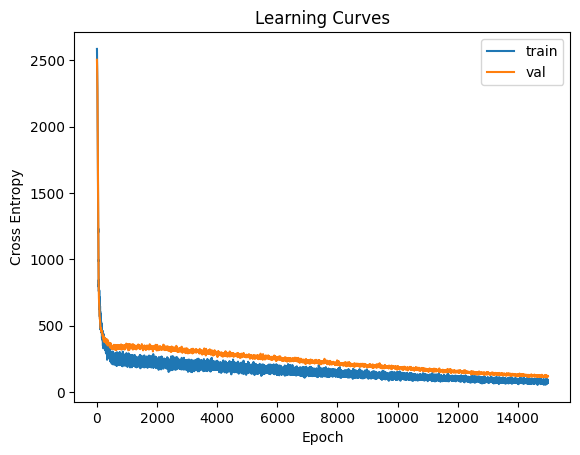

     Actual  Predicted   Age
0      51.0  42.107121  51.0
1      59.0  41.986397  59.0
2      23.5  42.050678  23.5
3      23.5  42.085262  23.5
4      77.0  41.989635  77.0
..      ...        ...   ...
108    51.0  38.868118  51.0
109    59.0  38.812366  59.0
110    44.5  38.908314  44.5
111    23.5  38.923782  23.5
112    77.0  49.998932  77.0

[113 rows x 3 columns]


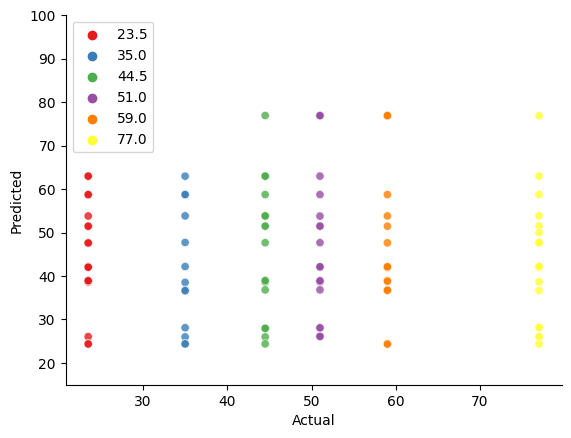

mae: 18.690587558577548, mse: 501.0171135602693, min: 24.341571807861328, max: 76.9481201171875
     Actual  Predicted   Age
0      51.0  42.107121  51.0
1      59.0  41.986397  59.0
2      23.5  42.050678  23.5
3      23.5  42.085262  23.5
4      77.0  41.989635  77.0
..      ...        ...   ...
108    51.0  38.868118  51.0
109    59.0  38.812366  59.0
110    44.5  38.908314  44.5
111    23.5  38.923782  23.5
112    77.0  49.998932  77.0

[113 rows x 3 columns]


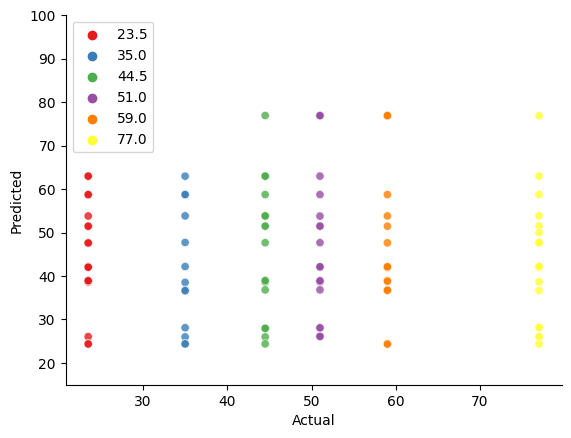

In [14]:
m.print_performance(my_model.history, results, my_model.z_test, save=True, skip_experiment=True)
m.plot_results(results, my_model.z_test, save=True, print_label='Age')

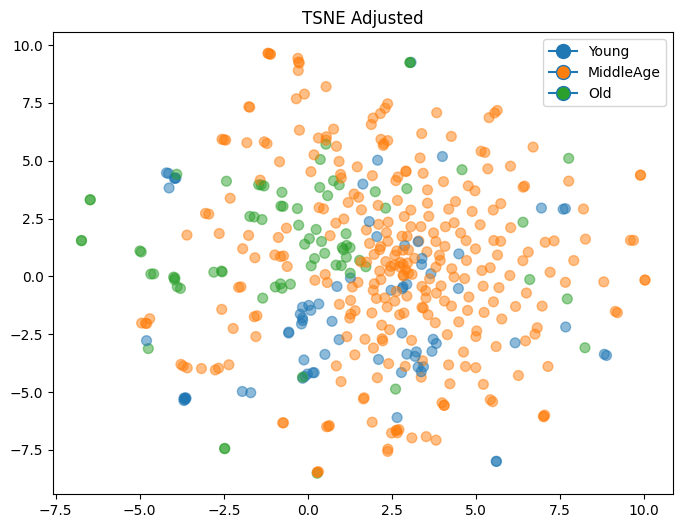

In [15]:
#m.print_performance(my_model.history, results, my_model.z_test, save=True, skip_experiment=True)

with open(f"{m.output_directory}/model_summary.txt", "a") as f:
    # Redirect the stdout to the file
    with redirect_stdout(f):
        print("Error: ")
        print(error)

save_performance_results(results, my_model)
clean_df_z = pd.DataFrame(my_model.z_test.values)
clean_df_z.columns = my_model.z_test.columns
results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
results_all_metadata.to_csv(f"{m.output_directory}/results_all_metadata.csv")
with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
    yaml.dump(conf_dic, yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
    yaml.dump(json.loads(my_model.model.to_json()), yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/selected_features.csv", "w") as f:
    f.write("\n".join(list(my_model.model_in_features)))

feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

In [16]:
results["Actual"].unique()

array([51. , 59. , 23.5, 77. , 35. , 44.5])

In [17]:
actual_categories = [23.5, 35, 44.5, 51, 59, 77]#[18,29,42,48,54,64,90]
actual_categories.sort()

# Function to find the closest category value
def find_closest_category(value):
    return min(actual_categories, key=lambda x: abs(x - value))

# Map predicted values to the closest actual categories
results['Predicted_round'] = results['Predicted'].apply(find_closest_category)

In [18]:
age_ranges = [{'label': '18-29', 'range': (18, 29.0), 'count': 88},
 {'label': '29-41', 'range': (29.0, 42), 'count': 85},
 {'label': '41-48', 'range': (42, 48), 'count': 97},
 {'label': '48-54', 'range': (48.0, 54), 'count': 79},
 {'label': '54-64', 'range': (54.0, 64), 'count': 85},
 {'label': '64-90', 'range': (64, 90), 'count': 87}]
def assign_age_group(age, age_groups):
    for group in age_groups:
        if group['range'][0] <= age < group['range'][1]:
            return group['label']
    return 'Unknown'
results['AgeGroup'] = results['Predicted'].apply(lambda x: assign_age_group(x, age_ranges))
results['AgeGroup']=results["AgeGroup"].str.split("-").apply(lambda x: (int(x[0])+int(x[1]))/2)
results['AgeGroup']


0      44.5
1      35.0
2      44.5
3      44.5
4      35.0
       ... 
108    35.0
109    35.0
110    35.0
111    35.0
112    51.0
Name: AgeGroup, Length: 113, dtype: float64

In [19]:
results['AgeGroup']

0      44.5
1      35.0
2      44.5
3      44.5
4      35.0
       ... 
108    35.0
109    35.0
110    35.0
111    35.0
112    51.0
Name: AgeGroup, Length: 113, dtype: float64

In [20]:
results["Actual"]

0      51.0
1      59.0
2      23.5
3      23.5
4      77.0
       ... 
108    51.0
109    59.0
110    44.5
111    23.5
112    77.0
Name: Actual, Length: 113, dtype: float64

Rounding to the closest center of category

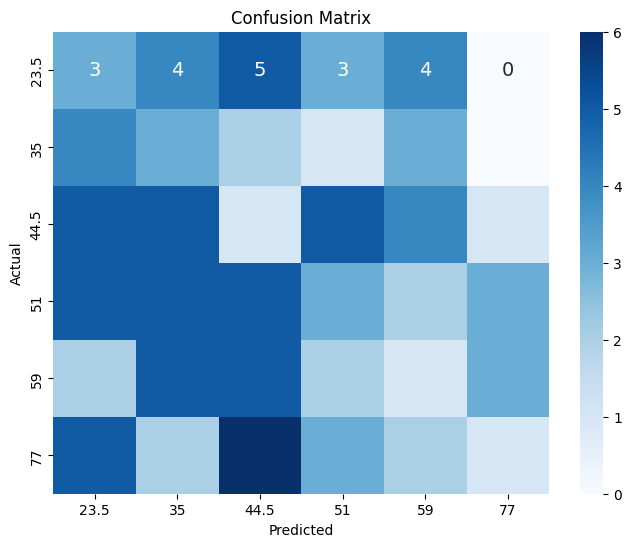

In [21]:
## Since smote make it categorical, I will take results to see the confusion matrix
results["Actual"] = results["Actual"].apply(lambda x: round(x))
results["Predicted_round"] = results["Predicted_round"].apply(lambda x: round(x))


# Create confusion matrix
conf_matrix = confusion_matrix(results['Actual'], results['Predicted_round'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=actual_categories, yticklabels=actual_categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

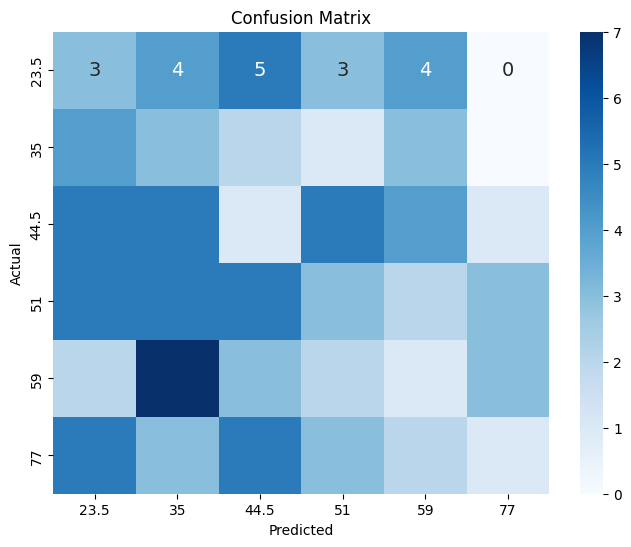

In [22]:
results["AgeGroup"] = results["AgeGroup"].apply(lambda x: round(x))

conf_matrix = confusion_matrix(results['Actual'], results['AgeGroup'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=actual_categories, yticklabels=actual_categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Assigning by age range

In [23]:
conf_matrix.shape

(6, 6)

## Catboost

### SMOTE data categorical

In [24]:
#!pip install catboost


In [25]:
X_train = normalized_X_train
X_test = normalized_X_test_fs
y_train = my_model.y_train
y_test = my_model.y_test


cat_features=[23, 35, 44, 51, 59, 77]
#X_train["Age"] = X_train["Age"].astype('category')
#X_test["Age"] = X_test["Age"].astype('category')
category_map = {23.5: 'Young', 35.0: 'MiddleAge_1', 44.5: 'MiddleAge_2', 51.0: 'MiddleAge_3', 59.0: 'MiddleAge_4', 77.0: 'Old'}
y_train_mapped = y_train.map(category_map)


# Initialize CatBoostClassifier
clf = CatBoostClassifier(iterations=100,  # Number of boosting iterations
                         learning_rate=0.1,  # Learning rate
                         depth=6,  # Depth of trees
                         random_state=42,  # Random seed for reproducibility
                         verbose=0)  # Verbosity level (0 - silent, 1 - verbose)

# Fit the model
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

y_pred_2 = [x[0] for x in y_pred]
#y_test.tolist()
y_pred_2

result_cat_df = pd.DataFrame({'Actual': y_test.tolist(), 'Predicted': y_pred_2})
result_cat_df

a= result_cat_df["Actual"]
a = a.map(category_map)
b= result_cat_df["Predicted"]
b = b.map(category_map)
result_cat_df_cate = result_cat_df.copy()
result_cat_df_cate["Actual"] = a
result_cat_df_cate["Predicted"] = b
# Evaluate accuracy
accuracy = accuracy_score(a, b)


In [26]:
accuracy

0.6106194690265486

     Actual  Predicted   Age
0      51.0       51.0  51.0
1      59.0       59.0  59.0
2      23.5       23.5  23.5
3      23.5       23.5  23.5
4      77.0       77.0  77.0
..      ...        ...   ...
108    51.0       35.0  51.0
109    59.0       77.0  59.0
110    44.5       44.5  44.5
111    23.5       23.5  23.5
112    77.0       77.0  77.0

[113 rows x 3 columns]


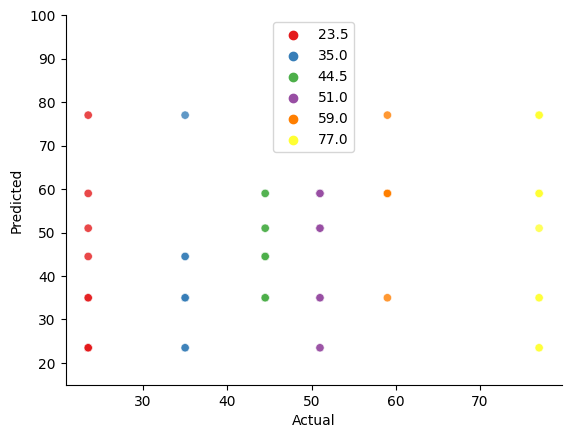

In [27]:
m.plot_results(result_cat_df, pd.DataFrame(y_test), save=True, print_label='Age')

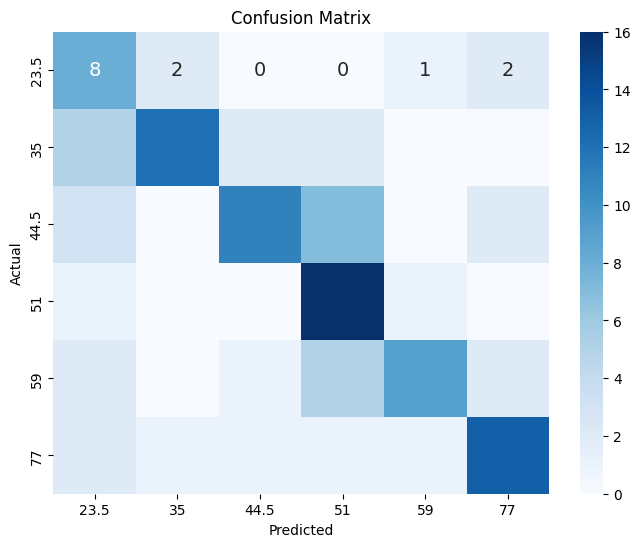

In [28]:


conf_matrix = confusion_matrix(result_cat_df_cate['Actual'], result_cat_df_cate['Predicted'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=actual_categories, yticklabels=actual_categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Now with regression

In [29]:


X_train = normalized_X_train
X_test = normalized_X_test_fs
y_train = my_model.y_train
y_test = my_model.y_test




# Initialize CatBoostClassifier
regressor = CatBoostRegressor(iterations=100,  # Number of boosting iterations
                              learning_rate=0.2,  # Learning rate
                              depth=4,  # Depth of trees
                              random_state=42,  # Random seed for reproducibility
                              verbose=1  # Verbosity level (0 - silent, 1 - verbose)
                            )

# Fit the model
regressor.fit(X_train, y_train, plot=True)

# Make predictions
y_pred = regressor.predict(X_test)

# Evaluate mean squared error
mse = mean_squared_error(y_test, y_pred)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 16.4802474	total: 16.1ms	remaining: 1.59s
1:	learn: 15.8544284	total: 27.9ms	remaining: 1.37s
2:	learn: 15.5126288	total: 39.8ms	remaining: 1.29s
3:	learn: 15.0717882	total: 51.3ms	remaining: 1.23s
4:	learn: 14.7039304	total: 64.2ms	remaining: 1.22s
5:	learn: 14.3066128	total: 75.2ms	remaining: 1.18s
6:	learn: 13.9501236	total: 88.2ms	remaining: 1.17s
7:	learn: 13.5225752	total: 103ms	remaining: 1.18s
8:	learn: 13.0922255	total: 118ms	remaining: 1.19s
9:	learn: 12.7311832	total: 131ms	remaining: 1.18s
10:	learn: 12.3886336	total: 145ms	remaining: 1.17s
11:	learn: 12.1290629	total: 157ms	remaining: 1.15s
12:	learn: 11.8918172	total: 170ms	remaining: 1.14s
13:	learn: 11.6354511	total: 182ms	remaining: 1.12s
14:	learn: 11.3077308	total: 194ms	remaining: 1.1s
15:	learn: 11.0403619	total: 205ms	remaining: 1.08s
16:	learn: 10.8216447	total: 221ms	remaining: 1.08s
17:	learn: 10.5773487	total: 235ms	remaining: 1.07s
18:	learn: 10.3751653	total: 251ms	remaining: 1.07s
19:	learn: 10.19

In [30]:
mse

153.4597460672293

In [31]:
result_cat_df = pd.DataFrame({'Actual': y_test.tolist(), 'Predicted': y_pred})
result_cat_df

,Actual,Predicted
0,51.0,48.457390
1,59.0,61.199840
2,23.5,44.025644
3,23.5,26.972336
4,77.0,66.657245
...,...,...
108,51.0,46.706536
109,59.0,45.351329
110,44.5,40.589581
111,23.5,20.634919


     Actual  Predicted   Age
0      51.0  48.457390  51.0
1      59.0  61.199840  59.0
2      23.5  44.025644  23.5
3      23.5  26.972336  23.5
4      77.0  66.657245  77.0
..      ...        ...   ...
108    51.0  46.706536  51.0
109    59.0  45.351329  59.0
110    44.5  40.589581  44.5
111    23.5  20.634919  23.5
112    77.0  63.163207  77.0

[113 rows x 3 columns]


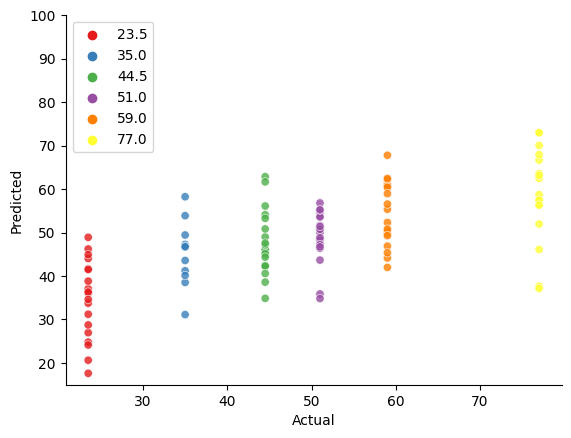

In [32]:
m.plot_results(result_cat_df, pd.DataFrame(y_test), save=True, print_label='Age')

In [33]:
a= result_cat_df["Actual"]
a = a.map(category_map)
b= result_cat_df["Predicted"]
b = b.map(category_map)
result_cat_df_cate = result_cat_df.copy()
result_cat_df_cate["Actual"] = a
result_cat_df_cate["Predicted"] = b

In [34]:
result_cat_df

,Actual,Predicted,Age
0,51.0,48.457390,51.0
1,59.0,61.199840,59.0
2,23.5,44.025644,23.5
3,23.5,26.972336,23.5
4,77.0,66.657245,77.0
...,...,...,...
108,51.0,46.706536,51.0
109,59.0,45.351329,59.0
110,44.5,40.589581,44.5
111,23.5,20.634919,23.5


In [35]:
conf_matrix = confusion_matrix(result_cat_df_cate['Actual'], result_cat_df_cate['Predicted'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=actual_categories, yticklabels=actual_categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ValueError: Classification metrics can't handle a mix of multiclass and unknown targets

###  Now the same trained model (Rregression) but the original data

In [36]:
all_rna_seq_data = pd.read_csv("Data/microarray_clean_status.csv")
data = m.remove_non_numeric_columns(all_rna_seq_data)
X = data.drop(columns=["Age"])
y = data["Age"]

In [37]:
z = all_rna_seq_data[['Experiment', 'Sex', 'Age', 'Status']]

In [38]:
X["Unnamed: 0"]=X.index
# move unnamed to the beggining of the df columns
cols = X.columns.tolist()
cols = cols[-1:] + cols[:-1]
X = X[cols]

In [39]:
X

,Unnamed: 0,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,...,AW050627,AI654857,W22117,AI028241,AI571298,AA149545,C18318,AI219073,AI205180,AI363375
0,0,-849.451525,684.683955,1114.042762,443.011786,370.785504,333.539739,-63.560513,292.844053,-42.396021,...,212.907160,100.942641,-23.282877,115.076069,200.367569,-453.626314,28.350612,-30.655708,-110.164419,13.685501
1,1,624.613602,-990.804989,520.933114,-259.200456,140.334490,-335.895743,-765.006958,-1.529941,-176.929439,...,-5.220516,-30.801400,-3.617812,-57.108664,13.075038,115.177630,-23.292205,-22.391904,-163.696077,156.188393
2,2,1366.490755,418.419632,-193.275408,-1652.056762,-139.000072,-112.750531,-334.777333,1504.490255,-74.446639,...,-24.523833,636.368973,1.466691,-67.935413,-113.608556,3062.905142,22.909984,23.340741,-177.242196,273.618650
3,3,3380.218284,-236.776886,-508.407888,609.246474,-246.543889,-58.608822,-246.666284,-263.802821,266.239453,...,308.407860,222.019612,-2.421460,-94.806669,154.212474,63.768764,83.706885,4.747184,221.878734,108.026385
4,4,-2080.015569,1474.756831,676.435199,-537.686050,14.633937,418.041490,113.349783,-412.697338,-239.843599,...,201.528341,-15.562874,0.943285,2.634231,-162.678702,902.850206,-28.819197,77.243295,-51.736567,-107.427785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,517,2406.099299,701.108201,-1511.249588,1053.347813,1063.794543,1999.797718,4134.643295,3646.460018,-540.334718,...,57.641231,118.137475,6.420098,83.892239,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969
518,518,-2452.532495,-2303.183241,-6452.190043,-3239.090434,180.763818,-422.587745,-7201.027058,-359.355911,-360.395781,...,57.641231,118.137475,6.420098,83.892239,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969
519,519,3331.993545,-617.837803,-1575.834487,1153.877996,2557.323530,216.936671,-1722.457066,1878.259639,-184.111785,...,57.641231,118.137475,6.420098,83.892239,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969
520,520,4938.451319,-626.296478,-2498.615690,821.964991,5427.681408,1750.702499,-3665.622647,1101.640844,-170.896095,...,57.641231,118.137475,6.420098,83.892239,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969


In [40]:
normalized = my_model.scaler.transform(X)
normalized_df = pd.DataFrame(normalized, columns=X.columns)
normalized_df = normalized_df[my_model.model_in_features]
normalized_df

,Unnamed: 0,NM_173596,NM_005927,NM_145020,NM_033128,NM_153205,NM_152990,NM_015167,NM_021044,NM_152454,...,AW467516,AI039933,AI242408,AW612232,AW450601,R01161,X15306,AI949010,AI825877,AI161338
0,-1.773103,-0.051120,-0.602709,-0.912098,-0.764003,1.479881,-1.091439,-0.123465,1.099175,-0.555367,...,0.500625,1.051651,-0.677477,1.113039,2.293825,0.364807,-0.962977,-1.544766,0.093707,-0.539263
1,-1.766924,-0.164293,-0.662363,-0.164818,-0.409353,-1.292432,0.120664,-1.247666,-1.629227,-0.586916,...,-0.392939,-1.199337,-1.330411,-1.230238,-0.445023,-0.099566,0.753370,-1.463189,0.487787,0.241392
2,-1.760745,0.055441,-1.500610,-0.474892,0.099143,1.542154,-0.076074,0.674656,1.053303,-0.623140,...,-0.734596,0.582574,-1.259785,-0.367226,0.356790,2.520391,-0.942617,-1.057230,-0.961574,0.283492
3,-1.754566,-0.164293,-1.079944,-0.132260,0.404365,0.264399,1.434469,-0.826867,-1.020921,1.618049,...,1.021870,0.043789,-0.433888,0.495786,-0.653201,-0.744416,2.555228,-1.097055,1.152036,-1.585748
4,-1.748387,0.069683,-0.040106,-0.642333,-0.574321,1.498332,-1.304849,-0.576872,0.235580,-0.491099,...,2.092832,0.704563,-0.405061,-0.092891,0.795916,-0.113761,-0.449905,-0.131618,-0.370454,1.902537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,1.421447,-1.795850,2.347736,4.334918,-2.717059,-0.164738,-2.521450,-0.198420,2.403398,1.412107,...,-0.011751,-0.056137,0.019911,-0.015308,0.032618,0.005670,-0.001452,-0.000997,0.026742,-0.044036
518,1.427626,-5.418904,-4.553481,1.953510,-5.802475,-0.149423,-1.393360,0.887363,0.708263,-0.239945,...,-0.011751,-0.056137,0.019911,-0.015308,0.032618,0.005670,-0.001452,-0.000997,0.026742,-0.044036
519,1.433805,-3.673463,0.885449,1.158757,0.180301,-0.140985,0.594289,-0.159767,1.684270,1.458795,...,-0.011751,-0.056137,0.019911,-0.015308,0.032618,0.005670,-0.001452,-0.000997,0.026742,-0.044036
520,1.439984,-3.931347,3.690965,6.029738,-1.689054,-0.166195,0.133450,-0.231384,1.868629,0.101012,...,-0.011751,-0.056137,0.019911,-0.015308,0.032618,0.005670,-0.001452,-0.000997,0.026742,-0.044036


In [41]:
y_pred = regressor.predict(normalized_df)

# Evaluate mean squared error


In [42]:
y_pred

array([42.68341209, 43.53568412, 43.57387274, 44.79128524, 42.55861795,
       44.85839503, 44.46931097, 43.58800944, 44.90101767, 44.8691276 ,
       50.03978737, 45.032795  , 42.42061254, 43.32215916, 40.58958065,
       44.09732177, 45.72921538, 44.3401396 , 44.37516073, 43.82593185,
       46.45631384, 43.01327425, 43.09479105, 42.73130525, 45.46964528,
       44.61697455, 45.35873767, 53.26628575, 48.99408032, 45.44129517,
       49.42961581, 45.50736485, 34.86468236, 46.53605103, 56.09893099,
       62.84587218, 35.53143749, 26.43517771, 72.97169259, 63.16320745,
       76.51860702, 72.89163603, 74.46143952, 38.81798343, 28.74982467,
       27.91725727, 78.21850828, 73.67962967, 26.24082991, 23.00625621,
       73.79619501, 78.06659616, 24.04424897, 46.1017295 , 71.53679636,
       25.07377317, 37.6531444 , 26.42068055, 23.63200064, 48.85667446,
       36.58813445, 35.50889048, 38.52613677, 38.59257699, 34.32474179,
       50.9618239 , 55.24355728, 58.46115234, 52.92604753, 48.36

In [43]:
mse = mean_squared_error(y, y_pred)

In [44]:
mse

41.71660011125199

In [45]:
result_cat_df_reg = pd.DataFrame({'Actual': y.tolist(), 'Predicted': y_pred})
result_cat_df_reg

,Actual,Predicted
0,45.51,42.683412
1,46.04,43.535684
2,43.39,43.573873
3,43.37,44.791285
4,44.40,42.558618
...,...,...
517,65.10,79.477423
518,68.40,63.577166
519,65.90,77.925035
520,67.30,75.782015


     Actual  Predicted Experiment
0     45.51  42.683412   GSE13070
1     46.04  43.535684   GSE13070
2     43.39  43.573873   GSE13070
3     43.37  44.791285   GSE13070
4     44.40  42.558618   GSE13070
..      ...        ...        ...
517   65.10  79.477423    GSE9676
518   68.40  63.577166    GSE9676
519   65.90  77.925035    GSE9676
520   67.30  75.782015    GSE9676
521   67.90  75.055669    GSE9676

[522 rows x 3 columns]


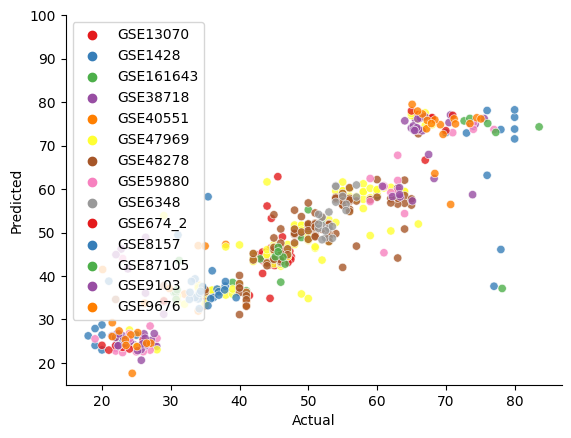

In [46]:
m.plot_results(result_cat_df_reg, z, save=True, print_label='Experiment')

# Plot scatter plot with color according to 'Experiment' column in results DataFrame

    # Create scatter plot with hue='Experiment' to group by Experiment category



In [47]:
print_label='Sex'
sns.scatterplot(x='Actual', y='Predicted', hue=print_label, data=result_cat_df_reg, palette='Set1', alpha=0.8, edgecolor='w')
# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()


ValueError: Could not interpret value `Sex` for parameter `hue`

In [ ]:
print_label='Status'
sns.scatterplot(x='Actual', y='Predicted', hue=print_label, data=result_cat_df_reg, palette='Set1', alpha=0.8, edgecolor='w')
# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [ ]:

# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=result_cat_df_reg, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

# Trying the model with the original data

In [ ]:
all_rna_seq_data = pd.read_csv("Data/RNAseq_All_abundances_adjusted.csv")

In [ ]:
data = m.remove_non_numeric_columns(all_rna_seq_data)
X = data.drop(columns=["Age"])
y = data["Age"]

In [ ]:
training_data.columns

In [ ]:
X["Unnamed: 0"]=X.index
# move unnamed to the beggining of the df columns
cols = X.columns.tolist()
cols = cols[-1:] + cols[:-1]
X = X[cols]

In [ ]:
normalized = my_model.scaler.transform(X)
normalized_df = pd.DataFrame(normalized, columns=X.columns)
normalized_df = normalized_df[my_model.model_in_features]
normalized_df

In [ ]:
y

In [ ]:
#normalized_X_train_original, normalized_X_test_fs_original = my_model.prepare_data(df=all_rna_seq_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)

In [ ]:

results, error = my_model.test(normalized_df, y)


In [ ]:
z = pd.DataFrame(all_rna_seq_data[["Experiment"]])
z

In [ ]:
z

In [ ]:
m.plot_results(results, z, save=False)

In [ ]:
my_model.model.predict(normalized_df)

Lets try with clusters; TSNE

In [ ]:
feature_df = pd.DataFrame(my_model.X_train)
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

In [ ]:


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

In [ ]:
feature_df = pd.DataFrame(training_data)
color_feature_selction_TSNE(feature_df)

In [ ]:
training_data.columns